C:\Users\Administrator\AppData\Local\Temp\ipykernel_24924\2856696745.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


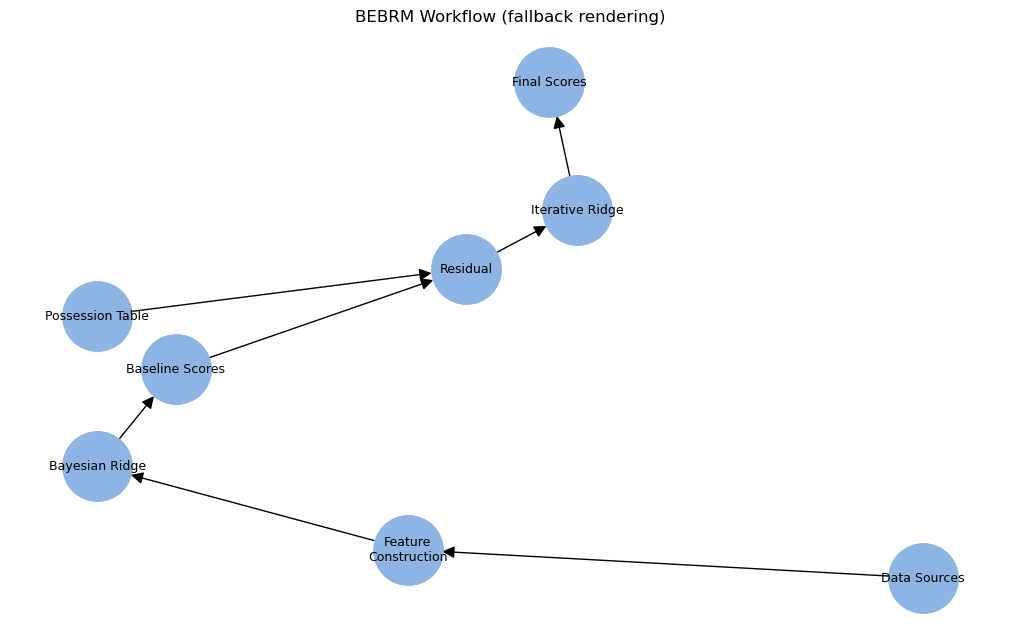

In [3]:
!pip install networkx
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

nodes = {
    'A': 'Data Sources',
    'B': 'Feature\nConstruction',
    'C': 'Bayesian Ridge',
    'D': 'Baseline Scores',
    'E': 'Possession Table',
    'F': 'Residual',
    'G': 'Iterative Ridge',
    'H': 'Final Scores'
}

G.add_edges_from([
    ('A','B'), ('B','C'), ('C','D'),
    ('D','F'), ('E','F'), ('F','G'), ('G','H')
])

pos = nx.spring_layout(G, seed=7)  # 也可手动指定坐标
plt.figure(figsize=(10,6))
nx.draw(G, pos, with_labels=True, labels=nodes,
        node_color="#8DB4E2", node_size=2500,
        font_size=9, arrowstyle='-|>', arrowsize=18)
plt.title("BEBRM Workflow (fallback rendering)")
plt.axis('off')
plt.tight_layout()
plt.show()



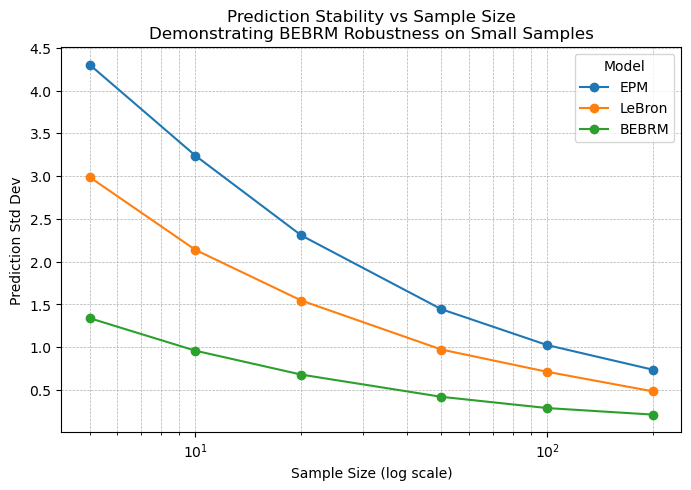

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate stability of three models vs sample size
np.random.seed(2025)
sample_sizes = np.array([5, 10, 20, 50, 100, 200])
reps = 1000
true_rating = 50

# Noise scale constants for each model
noise_constants = {
    'EPM': 10,
    'LeBron': 7,
    'BEBRM': 3
}

# Compute empirical std deviation of predictions
std_results = {model: [] for model in noise_constants}
for model, c in noise_constants.items():
    for n in sample_sizes:
        preds = true_rating + np.random.normal(0, c / np.sqrt(n), size=reps)
        std_results[model].append(preds.std())

# Plot
plt.figure(figsize=(8, 5))
for model, stds in std_results.items():
    plt.plot(sample_sizes, stds, marker='o', label=model)

plt.xscale('log')
plt.xlabel('Sample Size (log scale)')
plt.ylabel('Prediction Std Dev')
plt.title('Prediction Stability vs Sample Size\nDemonstrating BEBRM Robustness on Small Samples')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend(title="Model")
plt.show()
